# ISPRA 2020 hydraulic hazard coverage check for Italy

This notebook explores the raw ISPRA hydraulic-hazard shapefiles in `data/raw/Mosaicatura_ISPRA_2020_aree_pericolosita_idraulica`, overlays them on an Italy outline from the local Eurostat NUTS GeoPackage, and helps answer two practical questions:

- do the raw geometries plot over all of Italy?
- are any Italian NUTS2 regions completely untouched by the combined hazard footprint?

Important: these are flood-hazard polygons, not a wall-to-wall land-cover layer. Empty areas are normal. The goal here is to verify national extent and obvious gaps, not to expect 100% areal coverage of Italy.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root containing data/raw.")


ROOT = find_repo_root(Path.cwd().resolve())
SITE_PACKAGES = ROOT / ".venv" / "Lib" / "site-packages"
if SITE_PACKAGES.exists() and str(SITE_PACKAGES) not in sys.path:
    sys.path.insert(0, str(SITE_PACKAGES))

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

plt.rcParams["figure.figsize"] = (12, 10)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

ROOT

WindowsPath('D:/M2_MoSEF/DataCollection')

In [2]:
RAW_DIR = ROOT / "data" / "raw" / "Mosaicatura_ISPRA_2020_aree_pericolosita_idraulica"
NUTS_PATH = ROOT / "data" / "raw" / "NUTS_RG_20M_2024_4326.gpkg"

LAYER_PATHS = {
    "LPH - Low hazard": RAW_DIR / "LPH_Mosaicatura_ISPRA_2020_pericolosita_idraulica_bassa.shp",
    "MPH - Medium hazard": RAW_DIR / "MPH_Mosaicatura_ISPRA_2020_pericolosita_idraulica_media.shp",
    "HPH - High hazard": RAW_DIR / "HPH_Mosaicatura_ISPRA_2020_pericolosita_idraulica_elevata.shp",
}

for path in [*LAYER_PATHS.values(), NUTS_PATH]:
    assert path.exists(), f"Missing file: {path}"

file_inventory = pd.DataFrame(
    {
        "name": [path.name for path in [*LAYER_PATHS.values(), NUTS_PATH]],
        "relative_path": [str(path.relative_to(ROOT)) for path in [*LAYER_PATHS.values(), NUTS_PATH]],
        "size_mb": [round(path.stat().st_size / 1_048_576, 1) for path in [*LAYER_PATHS.values(), NUTS_PATH]],
    }
)

display(file_inventory)

,name,relative_path,size_mb
0,LPH_Mosaicatura_ISPRA_2020_pericolosita_idraul...,data\raw\Mosaicatura_ISPRA_2020_aree_pericolos...,339.8
1,MPH_Mosaicatura_ISPRA_2020_pericolosita_idraul...,data\raw\Mosaicatura_ISPRA_2020_aree_pericolos...,368.6
2,HPH_Mosaicatura_ISPRA_2020_pericolosita_idraul...,data\raw\Mosaicatura_ISPRA_2020_aree_pericolos...,327.7
3,NUTS_RG_20M_2024_4326.gpkg,data\raw\NUTS_RG_20M_2024_4326.gpkg,1.3


In [3]:
COLOR_MAP = {
    "LPH - Low hazard": "#4cc9f0",
    "MPH - Medium hazard": "#f4a261",
    "HPH - High hazard": "#d62828",
}

READ_KWARGS = {"engine": "pyogrio", "use_arrow": True}


def load_italy_boundary(nuts_path: Path) -> gpd.GeoDataFrame:
    italy = gpd.read_file(
        nuts_path,
        where="CNTR_CODE = 'IT' AND LEVL_CODE = 0",
        columns=["NUTS_ID", "CNTR_CODE", "NUTS_NAME"],
        **READ_KWARGS,
    ).copy()
    if italy.empty:
        raise ValueError("Could not find the Italy boundary in the NUTS GeoPackage.")
    if italy.crs is None:
        raise ValueError("Italy boundary has no CRS.")
    if italy.crs.to_epsg() != 4326:
        italy = italy.to_crs(4326)
    return italy


def load_italy_regions(nuts_path: Path, level: int = 2) -> gpd.GeoDataFrame:
    regions = gpd.read_file(
        nuts_path,
        where=f"CNTR_CODE = 'IT' AND LEVL_CODE = {level}",
        columns=["NUTS_ID", "CNTR_CODE", "NUTS_NAME"],
        **READ_KWARGS,
    ).copy()
    if regions.empty:
        raise ValueError(f"Could not find Italy NUTS level {level} geometries.")
    if regions.crs is None:
        raise ValueError("Italy NUTS regions have no CRS.")
    if regions.crs.to_epsg() != 4326:
        regions = regions.to_crs(4326)
    return regions


def load_hazard_layer(path: Path, label: str) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path, columns=["scenario"], **READ_KWARGS).copy()
    if gdf.crs is None:
        raise ValueError(f"{path.name} has no CRS.")
    if gdf.crs.to_epsg() != 3035:
        gdf = gdf.to_crs(3035)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["hazard_level"] = label
    keep_cols = [col for col in ["hazard_level", "scenario", "geometry"] if col in gdf.columns]
    return gdf[keep_cols]


def geometry_union(gdf: gpd.GeoDataFrame):
    try:
        return gdf.geometry.union_all()
    except AttributeError:
        return gdf.unary_union


def bounds_record(label: str, gdf: gpd.GeoDataFrame) -> dict[str, object]:
    minx, miny, maxx, maxy = gdf.total_bounds
    return {
        "layer": label,
        "features": len(gdf),
        "crs": gdf.crs.to_string() if gdf.crs is not None else None,
        "minx": round(float(minx), 1),
        "miny": round(float(miny), 1),
        "maxx": round(float(maxx), 1),
        "maxy": round(float(maxy), 1),
        "width_km": round(float(maxx - minx) / 1000, 1),
        "height_km": round(float(maxy - miny) / 1000, 1),
    }


def make_preview_layer(gdf: gpd.GeoDataFrame, label: str, tolerance_m: float = 750.0) -> gpd.GeoDataFrame:
    preview = gdf.dissolve().reset_index(drop=True)
    preview["hazard_level"] = label
    preview["geometry"] = preview.geometry.simplify(tolerance_m, preserve_topology=True)
    return preview.to_crs(4326)

In [4]:
italy = load_italy_boundary(NUTS_PATH)
italy_3035 = italy.to_crs(3035)
italy_regions = load_italy_regions(NUTS_PATH, level=2)
italy_regions_3035 = italy_regions.to_crs(3035)

hazard_layers = {label: load_hazard_layer(path, label) for label, path in LAYER_PATHS.items()}
hazard_all = gpd.GeoDataFrame(
    pd.concat(hazard_layers.values(), ignore_index=True),
    geometry="geometry",
    crs="EPSG:3035",
)

print(f"Loaded {len(hazard_all):,} hazard polygons across {len(hazard_layers)} layers.")

Loaded 85,460 hazard polygons across 3 layers.


In [5]:
layer_summary = pd.DataFrame(
    [bounds_record("Italy outline", italy_3035)]
    + [bounds_record(label, gdf) for label, gdf in hazard_layers.items()]
)

layer_summary

,layer,features,crs,minx,miny,maxx,maxy,width_km,height_km
0,Italy outline,1,EPSG:3035,4055456.0,1519555.9,5047944.4,2665352.2,992.5,1145.8
1,LPH - Low hazard,27176,EPSG:3035,4057750.6,1528652.8,5048515.8,2647213.3,990.8,1118.6
2,MPH - Medium hazard,29493,EPSG:3035,4057750.6,1528652.8,5048501.0,2647213.3,990.8,1118.6
3,HPH - High hazard,28791,EPSG:3035,4062011.0,1528652.8,5048486.2,2619504.6,986.5,1090.9


## Static country-wide overlay

This plot uses the full polygons, not a simplified preview. If the layers are present across the peninsula and the islands, you should see them distributed across the whole Italy outline rather than clipped to one macro-area.

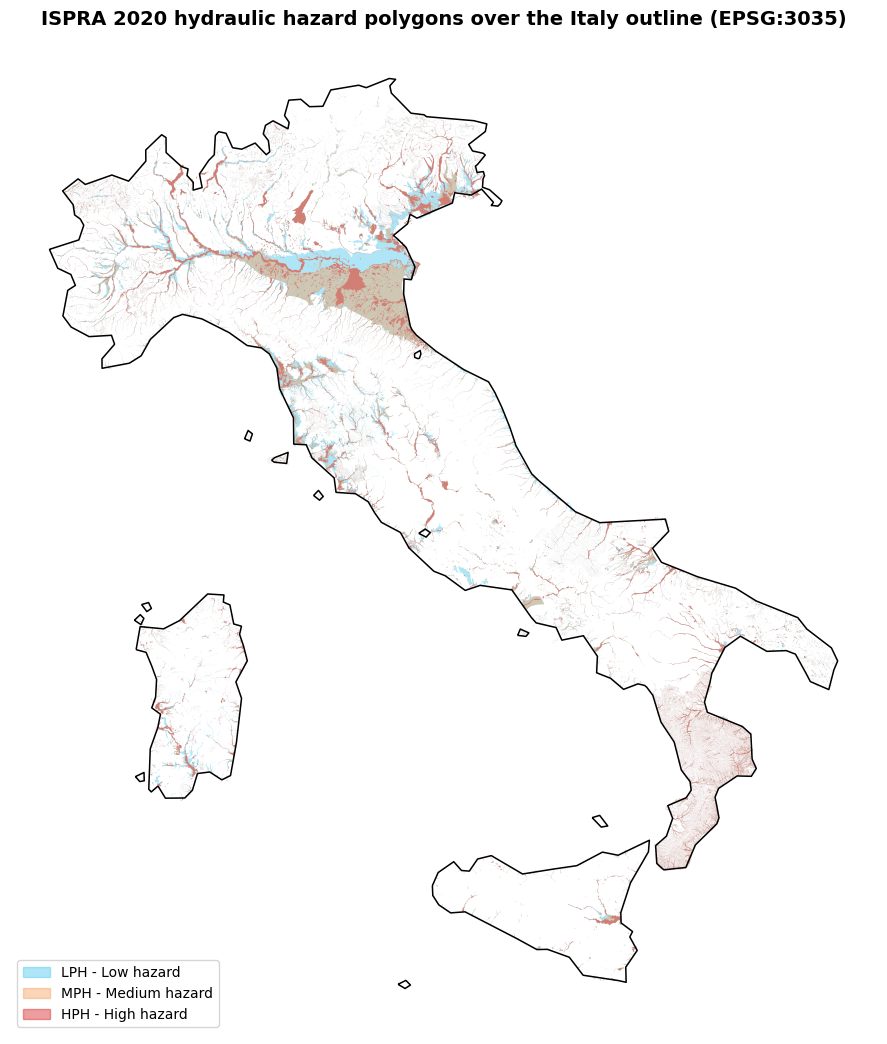

In [6]:
fig, ax = plt.subplots(figsize=(12, 13))
italy_3035.boundary.plot(ax=ax, color="black", linewidth=1.1)

for label, gdf in hazard_layers.items():
    gdf.plot(ax=ax, color=COLOR_MAP[label], alpha=0.45, linewidth=0)

legend_handles = [Patch(facecolor=COLOR_MAP[label], edgecolor=COLOR_MAP[label], alpha=0.45, label=label) for label in hazard_layers]
ax.legend(handles=legend_handles, loc="lower left")
ax.set_title("ISPRA 2020 hydraulic hazard polygons over the Italy outline (EPSG:3035)")
ax.set_axis_off()
plt.show()

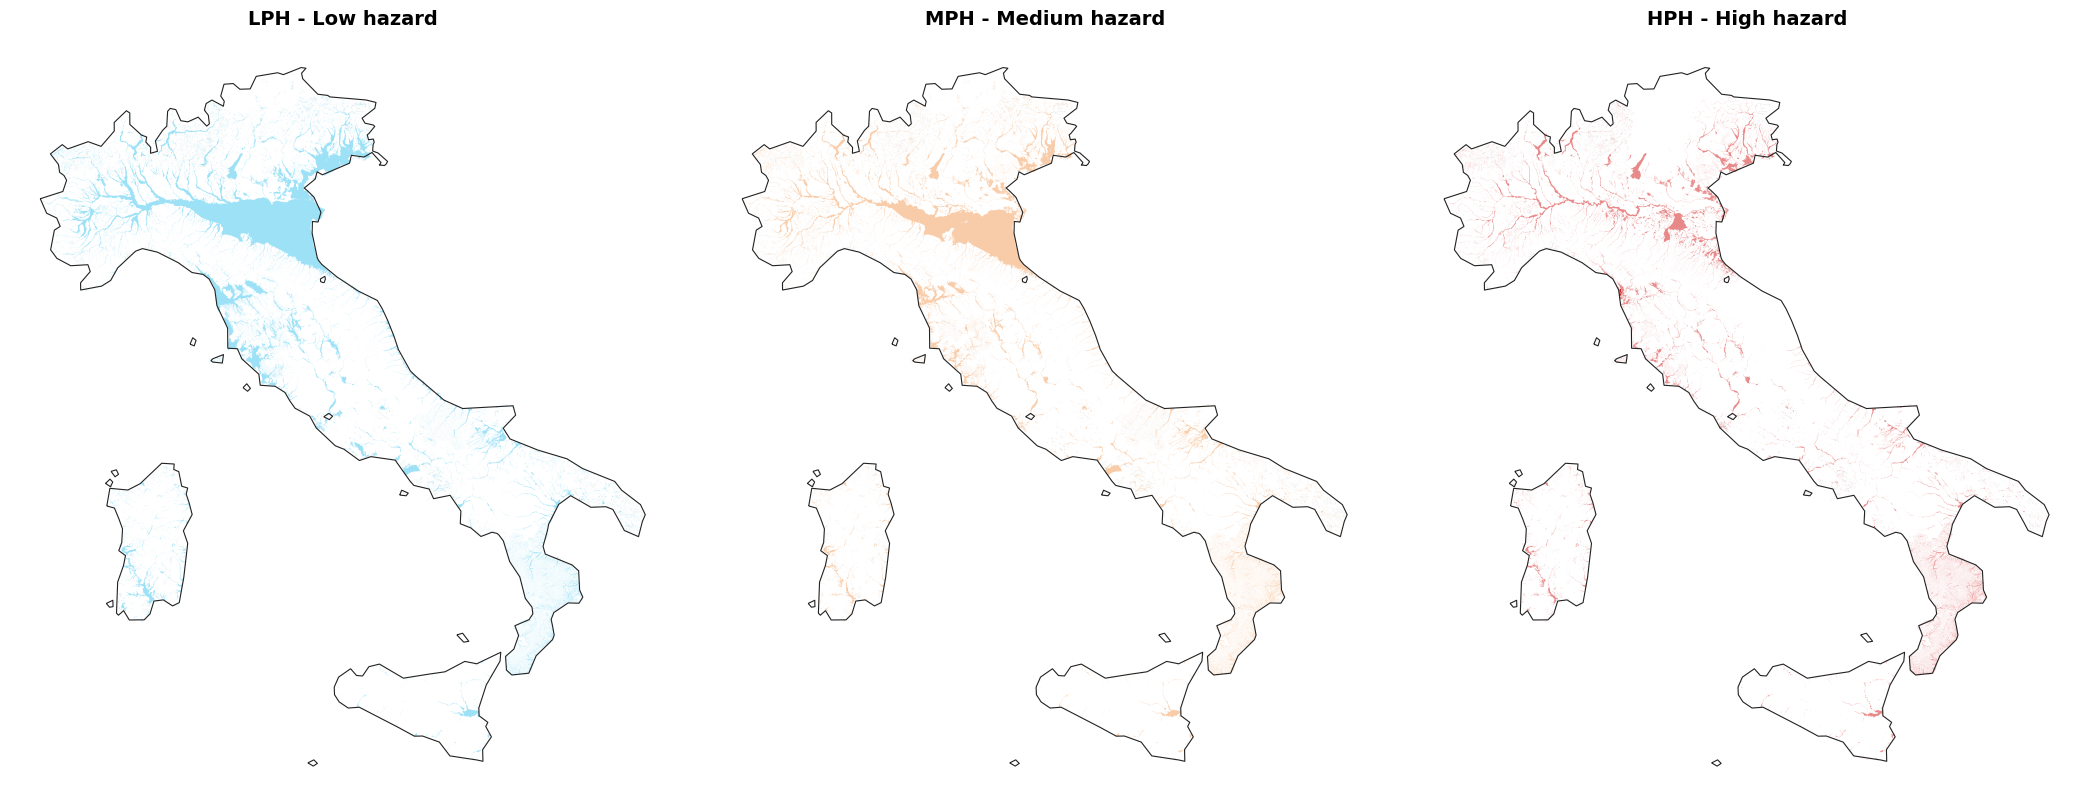

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8), constrained_layout=True)
for ax, (label, gdf) in zip(axes, hazard_layers.items()):
    italy_3035.boundary.plot(ax=ax, color="#222222", linewidth=0.8)
    gdf.plot(ax=ax, color=COLOR_MAP[label], alpha=0.55, linewidth=0)
    ax.set_title(label)
    ax.set_axis_off()
plt.show()

## Coverage diagnostic by Italian NUTS2 region

Because flood-hazard polygons do not cover every square kilometer, a better sanity check than area share is whether every Italian NUTS2 region intersects at least one hazard polygon somewhere.

In [8]:
region_hits = gpd.sjoin(
    italy_regions_3035[["NUTS_ID", "NUTS_NAME", "geometry"]],
    hazard_all[["hazard_level", "geometry"]],
    how="left",
    predicate="intersects",
)

coverage_by_region = (
    region_hits.groupby(["NUTS_ID", "NUTS_NAME"], as_index=False)["hazard_level"]
    .agg(lambda values: values.notna().any())
    .rename(columns={"hazard_level": "intersects_any_hazard"})
    .sort_values(["intersects_any_hazard", "NUTS_NAME"], ascending=[True, True])
    .reset_index(drop=True)
)

italy_regions_status = italy_regions_3035.merge(coverage_by_region, on=["NUTS_ID", "NUTS_NAME"], how="left")

print(
    f"Regions intersecting at least one hazard polygon: "
    f"{coverage_by_region['intersects_any_hazard'].sum()} / {len(coverage_by_region)}"
)

display(coverage_by_region)

missing_regions = coverage_by_region.loc[
    ~coverage_by_region["intersects_any_hazard"], "NUTS_NAME"
].tolist()
if missing_regions:
    print("Regions with no intersection:", ", ".join(missing_regions))
else:
    print("Every Italian NUTS2 region intersects at least one hazard polygon.")

Regions intersecting at least one hazard polygon: 21 / 21


,NUTS_ID,NUTS_NAME,intersects_any_hazard
0,ITF1,Abruzzo,True
1,ITF5,Basilicata,True
2,ITF6,Calabria,True
3,ITF3,Campania,True
4,ITH5,Emilia-Romagna,True
5,ITH4,Friuli-Venezia Giulia,True
6,ITI4,Lazio,True
7,ITC3,Liguria,True
8,ITC4,Lombardia,True
9,ITI3,Marche,True


Every Italian NUTS2 region intersects at least one hazard polygon.


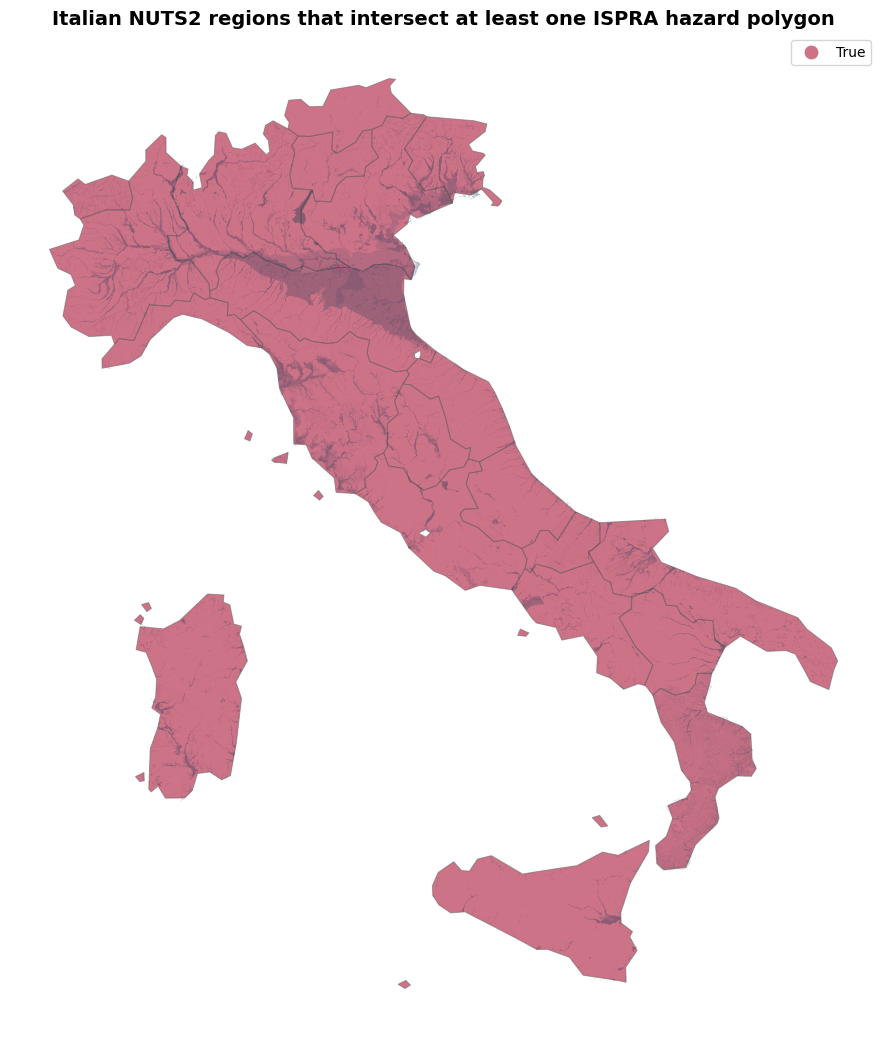

In [9]:
fig, ax = plt.subplots(figsize=(12, 13))
italy_regions_status.plot(
    ax=ax,
    column="intersects_any_hazard",
    categorical=True,
    legend=True,
    cmap="RdYlGn",
    alpha=0.55,
    edgecolor="#666666",
    linewidth=0.7,
)
hazard_all.plot(ax=ax, color="#003049", alpha=0.12, linewidth=0)
ax.set_title("Italian NUTS2 regions that intersect at least one ISPRA hazard polygon")
ax.set_axis_off()
plt.show()

## Optional interactive preview

The next cell creates a lighter interactive Folium map by dissolving each hazard layer and simplifying the geometry a bit. It is optional and can take a while on these large shapefiles. Use it for navigation and quick visual checks; use the static plots above when you want the full unsimplified geometry.

In [ ]:
italy_outline_wgs84 = italy.copy()
preview_layers = {label: make_preview_layer(gdf, label) for label, gdf in hazard_layers.items()}
center = italy_outline_wgs84.geometry.iloc[0].representative_point()

m = folium.Map(location=[center.y, center.x], zoom_start=5, tiles="CartoDB positron")

folium.GeoJson(
    italy_outline_wgs84.to_json(),
    name="Italy outline",
    style_function=lambda _: {"color": "black", "weight": 2, "fillOpacity": 0.0},
).add_to(m)

for label, preview in preview_layers.items():
    color = COLOR_MAP[label]
    folium.GeoJson(
        preview[["hazard_level", "geometry"]].to_json(),
        name=label,
        style_function=lambda _, color=color: {
            "color": color,
            "weight": 1.0,
            "fillColor": color,
            "fillOpacity": 0.35,
        },
        tooltip=folium.GeoJsonTooltip(fields=["hazard_level"], aliases=["Layer"]),
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m